## **Task 1**

Data retrieved from frost.met.no!


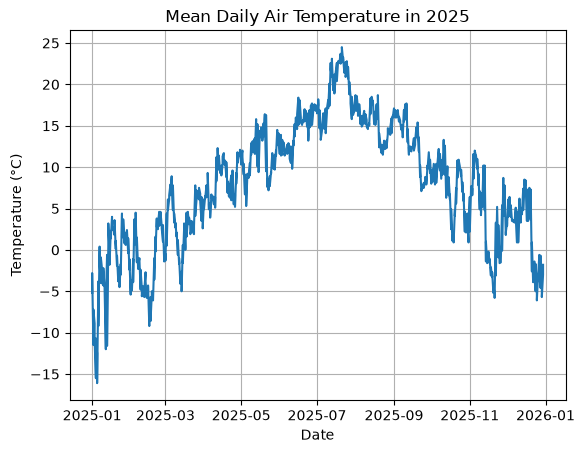

Statistic            Temperature (°C)
-------------------------------------
Mean                             7.90
Median                           8.35
Minimum                        -16.10
Maximum                         24.50


In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Read the client ID from a file
with open("../../frost_client_id.txt", "r") as file:
    client_id = file.read().strip()

# Define endpoint and parameters
endpoint = "https://frost.met.no/observations/v0.jsonld"
parameters = {
    "sources": "SN17850",
    "elements": "mean(air_temperature P1D)",
    "referencetime": "2025-01-01/2025-12-31",
}

# Issue an HTTP GET request
r = requests.get(endpoint, params=parameters, auth=(client_id, ""))

# Extract JSON data
json = r.json()

# Check if the request worked, print out any errors
if r.status_code == 200:
    data = json["data"]
    print("Data retrieved from frost.met.no!")
else:
    print("Error! Returned status code %s" % r.status_code)
    print("Message: %s" % json["error"]["message"])
    print("Reason: %s" % json["error"]["reason"])

# This will return a Dataframe with all of the observations in a table format
df = pd.DataFrame()
rows = []
for i in range(len(data)):
    row = pd.DataFrame(data[i]["observations"])
    row["referenceTime"] = data[i]["referenceTime"]
    row["sourceId"] = data[i]["sourceId"]
    rows.append(row)

df = pd.concat(rows, ignore_index=True)

# Extract temperatures and dates
temperatures = df["value"]

dates = pd.to_datetime(df["referenceTime"])

# Plot the data
plt.plot(dates, temperatures)

# Add labels and title to the plot
plt.title("Mean Daily Air Temperature in 2025")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)

plt.show()

# Calculate statistics
mean_temp = temperatures.mean()
median_temp = temperatures.median()
min_temp = temperatures.min()
max_temp = temperatures.max()

# Print the statistics in a formatted table
print(f"{'Statistic':<20} {'Temperature (°C)':>16}")
print("-" * 37)
print(f"{'Mean':<20} {mean_temp:>16.2f}")
print(f"{'Median':<20} {median_temp:>16.2f}")
print(f"{'Minimum':<20} {min_temp:>16.2f}")
print(f"{'Maximum':<20} {max_temp:>16.2f}")


## **Task 2**

Data retrieved from frost.met.no!


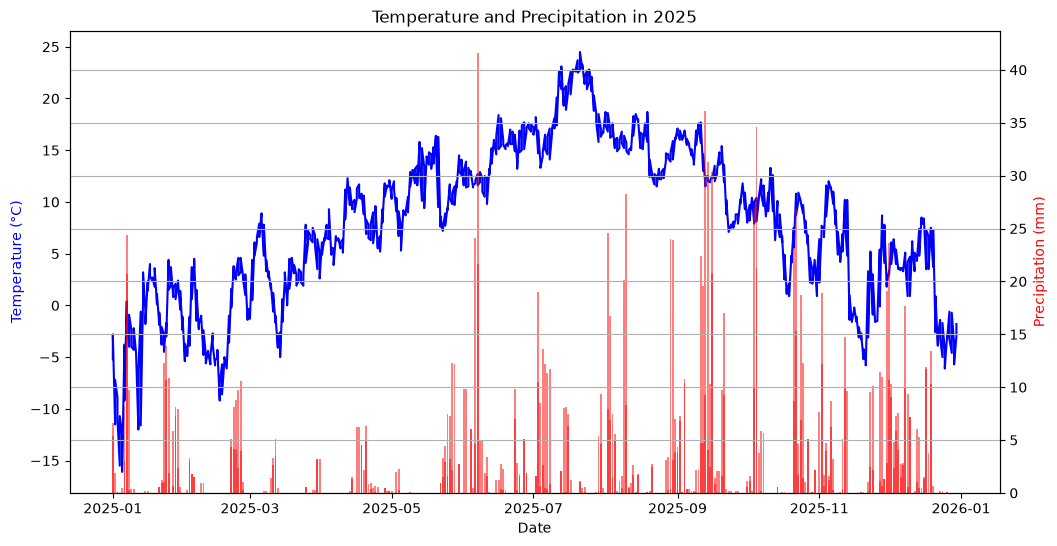

In [70]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Read the client ID from a file
with open("../../frost_client_id.txt", "r") as file:
    client_id = file.read().strip()

# Define endpoint and parameters
endpoint = "https://frost.met.no/observations/v0.jsonld"
parameters = {
    "sources": "SN17850",
    "elements": "mean(air_temperature P1D),sum(precipitation_amount P1D)",
    "referencetime": "2025-01-01/2025-12-31",
}

# Issue an HTTP GET request
r = requests.get(endpoint, params=parameters, auth=(client_id, ""))

# Extract JSON data
json = r.json()

# Check if the request worked, print out any errors
if r.status_code == 200:
    data = json["data"]
    print("Data retrieved from frost.met.no!")
else:
    print("Error! Returned status code %s" % r.status_code)
    print("Message: %s" % json["error"]["message"])
    print("Reason: %s" % json["error"]["reason"])

# This will return a Dataframe with all of the observations in a table format
df = pd.DataFrame()
rows = []
for i in range(len(data)):
    row = pd.DataFrame(data[i]["observations"])
    row["referenceTime"] = data[i]["referenceTime"]
    row["sourceId"] = data[i]["sourceId"]
    rows.append(row)

df = pd.concat(rows, ignore_index=True)

# Extract temperatures and precipitation data
temperatures = df[df["elementId"] == "mean(air_temperature P1D)"]["value"]
temperature_dates = pd.to_datetime(df[df["elementId"] == "mean(air_temperature P1D)"]["referenceTime"])

precipitations = df[df["elementId"] == "sum(precipitation_amount P1D)"]["value"]
precipitation_dates = pd.to_datetime(df[df["elementId"] == "sum(precipitation_amount P1D)"]["referenceTime"])

# Plot the data with two y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Temperature on the left y-axis
ax1.plot(
    temperature_dates,
    temperatures,
    color="blue",
    label="Temperature"
)
ax1.set_xlabel("Date")
ax1.set_ylabel("Temperature (°C)", color="blue")

# Create a new y-axis
ax2 = ax1.twinx()

# Precipitation on the right y-axis
ax2.bar(
    precipitation_dates,
    precipitations,
    color="red",
    alpha=0.5,
    label="Precipitation"
)
ax2.set_ylabel("Precipitation (mm)", color="red")

plt.title("Temperature and Precipitation in 2025")
plt.grid(True)
plt.show()
